# Advertising Sales Prediction

## Multiple Linear Regression

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the advertising dataset
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
# Examine the dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
display(df.describe())

Shape: (200, 4)

Columns:
['TV', 'Radio', 'Newspaper', 'Sales']

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Summary statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Feature Selection

In [5]:
# Select advertising spends as inputs and sales as the target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Input features:", X.columns.tolist())
print("Target:", y.name)

Input features: ['TV', 'Radio', 'Newspaper']
Target: Sales


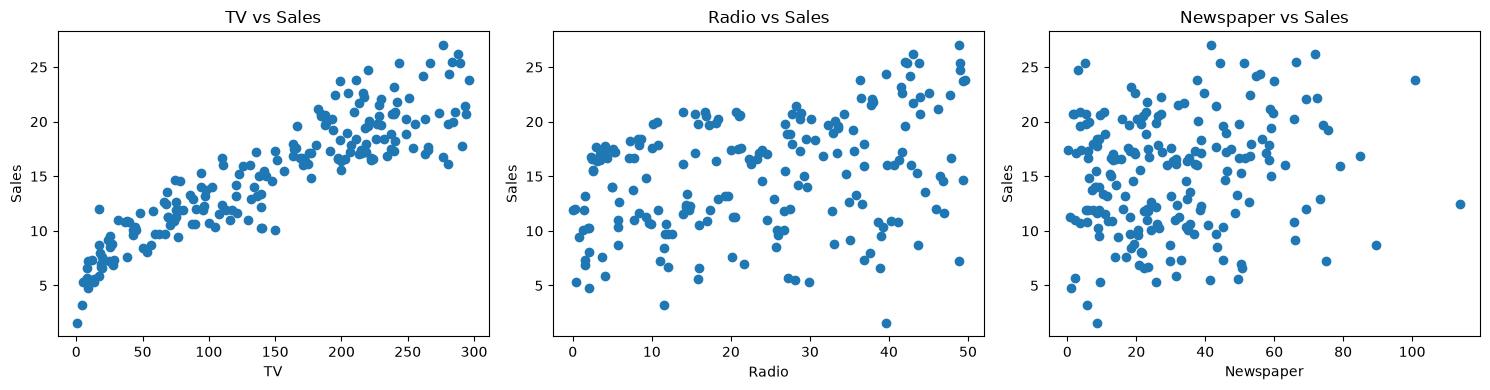

In [6]:
# Explore relationships between advertising channels and sales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[feature], df["Sales"])
    ax.set_xlabel(feature)
    ax.set_ylabel("Sales")
    ax.set_title(f"{feature} vs Sales")

plt.tight_layout()
plt.show()

## Model Training

In [7]:
# Split historical data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 160
Testing records: 40


In [8]:
# Train the multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 4.714126402214127

Coefficients:
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043


## Predict Sales for Unseen Data

In [9]:
# Predict sales for the test dataset
y_pred = model.predict(X_test)

prediction_results = X_test.copy()
prediction_results["Actual Sales"] = y_test.values
prediction_results["Predicted Sales"] = y_pred.round(2)

prediction_results.head(10)

,TV,Radio,Newspaper,Actual Sales,Predicted Sales
95,163.3,31.6,52.9,16.9,17.03
15,195.4,47.7,52.9,22.4,20.41
30,292.9,28.3,43.2,21.4,23.72
158,11.7,36.9,45.2,7.3,9.27
128,220.3,49.0,3.2,24.7,21.68
115,75.1,35.0,52.7,12.6,12.57
69,216.8,43.9,27.2,22.3,21.08
170,50.0,11.6,18.4,8.4,8.69
174,222.4,3.4,13.1,16.5,17.24
45,175.1,22.5,31.5,16.1,16.67


In [10]:
# Predict sales for the planned advertising budget
planned_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

planned_sales = model.predict(planned_budget)[0]

print("Planned advertising budget:")
display(planned_budget)
print(f"Predicted Sales: {planned_sales:.2f}")

Planned advertising budget:


,TV,Radio,Newspaper
0,150,20,30


Predicted Sales: 15.04


## Model Evaluation

In [11]:
# Calculate prediction error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
R-squared (R²): 0.9059


## Coefficient Interpretation

In [12]:
# Compare the effect of each advertising channel
coefficient_table = pd.DataFrame({
    "Advertising Medium": X.columns,
    "Coefficient": model.coef_
})

coefficient_table["Absolute Impact"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values(
    "Absolute Impact", ascending=False
)

display(coefficient_table)

,Advertising Medium,Coefficient,Absolute Impact
1,Radio,0.100945,0.100945
0,TV,0.054509,0.054509
2,Newspaper,0.004337,0.004337


### Interpretation

In a multiple linear regression model, each coefficient represents the expected change in Sales for a one-unit increase in that advertising channel while keeping the other channels constant.

The channel with the largest absolute coefficient has the strongest estimated effect per unit of advertising spend in this model.

The channel with the smallest absolute coefficient has the least estimated effect per unit, although business decisions should also consider the cost and scale of each advertising channel.

In [13]:
# Identify the strongest and weakest coefficients
strongest = coefficient_table.iloc[0]
weakest = coefficient_table.iloc[-1]

print(
    f"Strongest coefficient: {strongest['Advertising Medium']} "
    f"({strongest['Coefficient']:.4f})"
)
print(
    f"Weakest coefficient: {weakest['Advertising Medium']} "
    f"({weakest['Coefficient']:.4f})"
)

Strongest coefficient: Radio (0.1009)
Weakest coefficient: Newspaper (0.0043)


## Actual Sales vs Predicted Sales

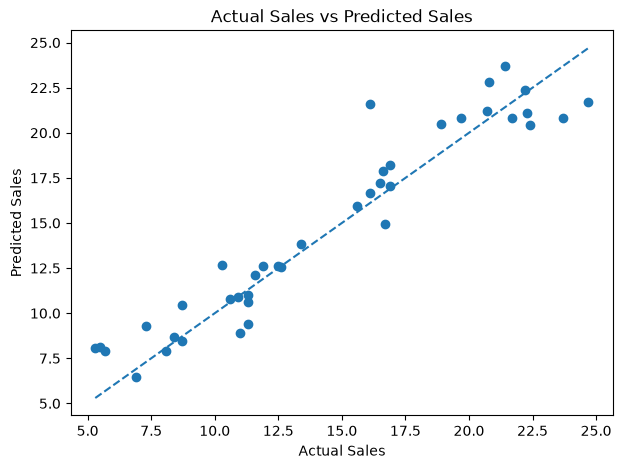

In [14]:
# Visualize actual sales against predicted sales
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.show()

## Business Recommendation

The company should prioritize the advertising channel that shows the strongest positive relationship with Sales, while considering the cost and return on investment of each channel. Advertising budget should be allocated based on both predicted sales impact and campaign profitability.

## Technical Improvement

A useful improvement would be to compare Linear Regression with nonlinear models such as Random Forest Regression or Gradient Boosting Regression and use cross-validation to select the model with the lowest prediction error and strongest generalization.

## Conclusion

Multiple Linear Regression was used because Sales is a continuous numerical target and the model can estimate how TV, Radio, and Newspaper spending jointly relate to Sales.

The trained model can predict sales for unseen advertising budgets, evaluate prediction error, and provide coefficients that help interpret the estimated contribution of each advertising channel.